# А/Б-тестирование в Cookie Cats: Перенос ворот с 30 на 40 уровень

### Бизнес-цель:
Оценить влияние изменения уровня, на котором игроки сталкиваются с первыми "воротами" (gate) — ограничением, требующим подождать или сделать микротранзакцию. Наша задача — понять, как перенос ворот с 30 на 40 уровень влияет на вовлеченность (количество раундов) и удержание игроков (Retention 1-го и 7-го дней).

### Описание признаков:
* `userid` — уникальный номер, идентифицирующий каждого игрока.
* `version` — группа игрока: `gate_30` (контрольная) или `gate_40` (целевая).
* `sum_gamerounds` — количество игровых раундов, сыгранных игроком в течение первых 14 дней после установки.
* `retention_1` — вернулся ли игрок в игру через 1 день после установки?
* `retention_7` — вернулся ли игрок в игру через 7 дней после установки?

In [1]:
import os
import kagglehub

In [2]:
import pandas as pd
import scipy.stats as ss

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

## 1. Загрузка и предобработка данных

In [4]:
# Скачиваем датасет с Kaggle и загружаем в DataFrame
path = kagglehub.dataset_download("mursideyarkin/mobile-games-ab-testing-cookie-cats")

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

df = pd.read_csv(full_path)

print(f"Размер датасета: {df.shape}")
df.head()

Размер датасета: (90189, 5)


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [6]:
df.isna().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

In [7]:
print(df['userid'].duplicated().sum())
print(df.duplicated().sum())

0
0


In [8]:
# Проверяем, насколько реальное распределение по группам отклоняется от идеального 50/50
srm_stat, srm_p = ss.chisquare([44699, 45489])
print(f"SRM тест p-value: {srm_p:.4f}")

SRM тест p-value: 0.0085


In [9]:
df = df[df['sum_gamerounds'] < 40000]

> **Примечание по предобработке:** Был обнаружен и удален критический выброс (игрок со значением `sum_gamerounds` > 40,000), который мог сильно исказить средние показатели групп.

## 2. Разведочный анализ данных (EDA)

In [10]:
# Смотрим среднее и медиану раундов по группам
df.groupby('version')['sum_gamerounds'].describe().reset_index()

,version,count,mean,std,min,25%,50%,75%,max
0,gate_30,44699.0,51.342111,102.057598,0.0,5.0,17.0,50.0,2961.0
1,gate_40,45489.0,51.298776,103.294416,0.0,5.0,16.0,52.0,2640.0


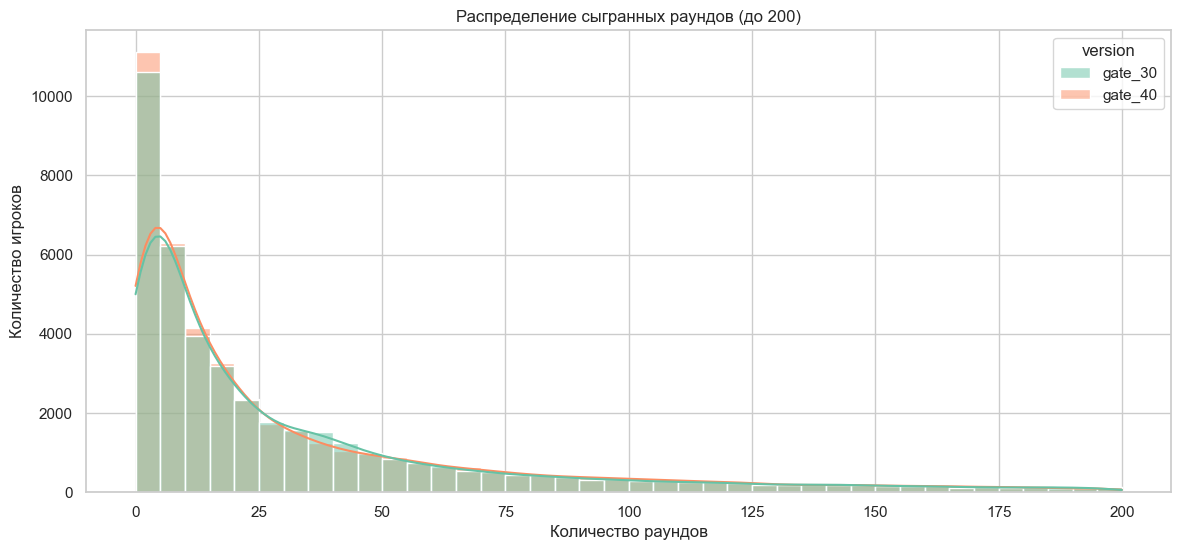

In [11]:
plt.figure(figsize=(14,6))

sns.histplot(data=df[df['sum_gamerounds'] <= 200], x='sum_gamerounds', hue='version', kde=True, bins=40, palette='Set2')

plt.title('Распределение сыгранных раундов (до 200)')
plt.xlabel('Количество раундов')
plt.ylabel('Количество игроков')

plt.show()

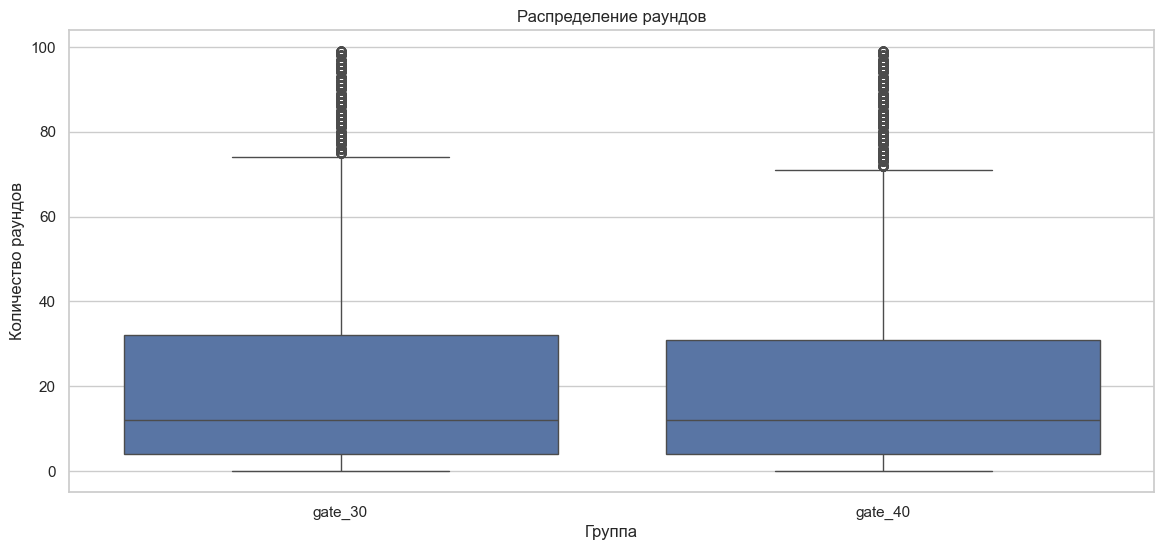

In [12]:
plt.figure(figsize=(14, 6))

sns.boxplot(data=df[df['sum_gamerounds'] < 100], x='version', y='sum_gamerounds')

plt.title('Распределение раундов')
plt.xlabel('Группа')
plt.ylabel('Количество раундов')

plt.show()

Фиксируем базовый уровень ошибки первого рода $\alpha = 0.05$. На основе него будем принимать или отклонять нулевые гипотезы

In [13]:
# Тест на нормальность данных (проверяем форму распределения)
print(ss.normaltest(df[df['version'] == 'gate_30']['sum_gamerounds']))
print(ss.normaltest(df[df['version'] == 'gate_40']['sum_gamerounds']))

NormaltestResult(statistic=np.float64(51730.04355110887), pvalue=np.float64(0.0))
NormaltestResult(statistic=np.float64(52497.05166731082), pvalue=np.float64(0.0))


In [14]:
# Сравниваем количество раундов в группах через Манна-Уитни
ss.mannwhitneyu(df[df['version'] == 'gate_30']['sum_gamerounds'], df[df['version'] == 'gate_40']['sum_gamerounds'])

MannwhitneyuResult(statistic=np.float64(1024285761.5), pvalue=np.float64(0.05089155279145376))

## 3. Статистическое тестирование (Удержание игроков)

In [15]:
# Считаем реальный % удержания 1-го и 7-го дня по группам
retention_1_mean = df.groupby('version')['retention_1'].mean().reset_index()
retention_7_mean = df.groupby('version')['retention_7'].mean().reset_index()

print(retention_1_mean)
print(retention_7_mean)

   version  retention_1
0  gate_30     0.448198
1  gate_40     0.442283
   version  retention_7
0  gate_30     0.190183
1  gate_40     0.182000


In [16]:
# Тест Хи-квадрат для Retention 1-го и 7-го дней
table_chi_ret1 = pd.crosstab(df['version'], df['retention_1'])
table_chi_ret7 = pd.crosstab(df['version'], df['retention_7'])

print(table_chi_ret1)
print(table_chi_ret7)

retention_1  False  True 
version                  
gate_30      24665  20034
gate_40      25370  20119
retention_7  False  True 
version                  
gate_30      36198   8501
gate_40      37210   8279


In [17]:
res_1 = ss.chi2_contingency(table_chi_ret1)
print(f"Retention 1-го дня: p-value = {res_1.pvalue:.4f} (statistic = {res_1.statistic:.2f})")
res_7 = ss.chi2_contingency(table_chi_ret7)
print(f"Retention 7-го дня: p-value = {res_7.pvalue:.4f} (statistic = {res_7.statistic:.2f})")

Retention 1-го дня: p-value = 0.0750 (statistic = 3.17)
Retention 7-го дня: p-value = 0.0016 (statistic = 9.92)


##  Общие выводы и рекомендации для бизнеса

### 1. Качество сплитования данных (SRM-тест)
* При проверке распределения объемов выборок (44 699 игроков в группе `gate_30` против 45 489 в `gate_40`) тест Хи-квадрат на равномерность выявил **Sample Ratio Mismatch** (`p-value = 0.0085`).
* **Вывод для бизнеса:** Наблюдается статистически значимый микроперекос в сторону целевой группы. На итоговые продуктовые выводы по метрикам удержания это не влияет из-за огромного объема данных, однако технической команде **рекомендуется проверить рандомизатор трафика** на платформе, чтобы исключить баги сплитования в будущих экспериментах.

### 2. Влияние на вовлеченность (Количество раундов)
* Распределение сыгранных раундов в обеих группах является сильно скошенным вправо (ненормальным), где среднее значение (~51) значительно превышает медиану (16-17).
* Критерий Манна-Уитни показал `p-value = 0.0511`. Это означает, что перенос ворот с 30 на 40 уровень **не имеет статистически значимого влияния** на общее количество сыгранных раундов.
* Снижение медианы с 17 до 16 признано **статистическим шумом**, так как типичный (медианный) игрок покидает игру задолго до того, как физически добирается до первой контрольной точки.

### 3. Влияние на краткосрочное удержание (Retention 1)
* На 1-й день удержание в контрольной группе (`gate_30`) составило 44.82%, а в целевой (`gate_40`) — 44.23%.
* Критерий Хи-квадрат выдал `p-value = 0.0750`. Формально, при строгом пороге $\alpha = 0.05$, мы не можем отклонить нулевую гипотезу о равенстве групп. Однако на выборке в 90 000 человек такой результат указывает на **выраженный негативный тренд** (маргинальную значимость), который полностью раскрывается и подтверждается уже на 7-й день эксперимента.

### 4. Влияние на долгосрочное удержание (Retention 7)
* На 7-й день удержание в группе с ранними воротами (`gate_30`) оказалось значимо выше — 19.02% против 18.20% в группе `gate_40`.
* Тест Хи-квадрат зафиксировал высокую статистическую значимость различий (`p-value = 0.0016`). Вероятность получить такое расхождение случайно составляет всего 0.16%.
* **Психологическое обоснование:** Ранние ворота на 30 уровне эффективно дозируют удовольствие от геймплея (эффект гедонистической адаптации). Ограничение прерывает игровой процесс на пике интереса (эффект клиффхэнгера), создавая чувство легкой недосказанности и мотивируя игроков возвращаться в приложение спустя неделю. Если барьер отодвинуть до 40 уровня, пользователи успевают пресытиться механикой игры и быстрее выгорают.

---

###  Финальная рекомендация команде разработки:

1. **Отказываемся от раскатки изменений:** Оставляем первые ворота строго на **30-м уровне**. Перенос ворот на 40-й уровень не дает бизнесу никаких плюсов в количестве раундов, но при этом гарантированно и значимо роняет долгосрочный Retention 7 (почти на 1%), что критично для LTV и монетизации игры.
2. **Запускаем обратный тест («на уменьшение»):** На основе полученных инсайтов рекомендуется спроектировать новый А/Б-тест, в котором первые ворота будут сдвинуты еще ближе к началу (например, на 20-й или 25-й уровень). Наша цель — проверить, сможем ли мы еще сильнее поднять долгосрочное удержание, дозируя контент раньше, не навредив при этом общей вовлеченности игроков.